# PART 4: ENGAGEMENT COMPARISON

This notebook compares audience engagement between **institutional** and **independent** science YouTube channels.

Focus:
- Views, likes, comments and combined engagement
- Engagement rates over the existence of the channels
- Group medians
- Boxplots
- Mann–Whitney U tests
- Channel-level summaries

Methodological note: videos are nested within channels. Therefore, this notebook reports both **video-level** comparisons and more conservative **channel-level** comparisons.


## IMPORTS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from pathlib import Path
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

COLOR_INST = "#FC8D62"
COLOR_IND = "#66C2A5"
COLOR_MAP = {"Institutional": COLOR_INST, "Independent": COLOR_IND}
GROUP_ORDER = ["Institutional", "Independent"]

## SET-UP

The cell below tries several common locations for the project files.  
It will work if `videos.csv` and `channels.csv` are:
- in the same folder as this notebook,
- in `../processed/`,
- in `../../processed/`,
- or, in this ChatGPT environment, in `/mnt/data/`.


In [2]:


videos_path = "/Users/oliviarobles/Downloads/CSM-projet/videos.csv"
channels_path = "/Users/oliviarobles/Downloads/CSM-projet/channels.csv"

print("Using videos file:", videos_path)
print("Using channels file:", channels_path)

data = pd.read_csv(videos_path)
channel_data = pd.read_csv(channels_path)

display(data.head())
display(channel_data.head())

Using videos file: /Users/oliviarobles/Downloads/CSM-projet/videos.csv
Using channels file: /Users/oliviarobles/Downloads/CSM-projet/channels.csv


,video_id,channel_id,published_at,title,description,duration_iso8601,duration_seconds,view_count,like_count,comment_count,thumbnail_url_default,thumbnail_url_high,tags,privacy_status_if_available
0,--4MpKow8ro,UC-EnprmCZ3OXyAoG7vjVNCA,2011-06-07T00:01:03Z,NExT: Bing Overseas Studies,"(June 2, 2011) Students Aleema Jamal and Matth...",PT2M7S,127.0,3119.0,8.0,1.0,https://i.ytimg.com/vi/--4MpKow8ro/default.jpg,https://i.ytimg.com/vi/--4MpKow8ro/hqdefault.jpg,Undergraduate Education|Diversity|Culture|Hist...,public
1,--ZfVZbmKbY,UC-EnprmCZ3OXyAoG7vjVNCA,2017-05-07T22:57:29Z,Mark Hartney: ARPA-E and Funding R&D of Advanc...,Mark Hartney is the director of the Office of ...,PT1H2M51S,3771.0,4314.0,38.0,NaN,https://i.ytimg.com/vi/--ZfVZbmKbY/default.jpg,https://i.ytimg.com/vi/--ZfVZbmKbY/hqdefault.jpg,NaN,public
2,--aYHgPKGIs,UCRNo2gqj3GiHlmT_OnqkouA,2017-06-15T05:47:25Z,ETH Zürich: Bereit?,Dann Los! Erfahre in 120 Sekunden das Wichtigs...,PT2M9S,129.0,99700.0,1038.0,17.0,https://i.ytimg.com/vi/--aYHgPKGIs/default.jpg,https://i.ytimg.com/vi/--aYHgPKGIs/hqdefault.jpg,ETH Zürich|ETH|Hochschule|Universität|Spitzenf...,public
3,--qKOhdgJAs,UC-EnprmCZ3OXyAoG7vjVNCA,2021-05-24T15:00:17Z,Lecture 3: MVVM and the Swift type system,Lecture 3 of Stanford’s Spring 2021 iteration ...,PT1H35M48S,5748.0,178472.0,2432.0,NaN,https://i.ytimg.com/vi/--qKOhdgJAs/default.jpg,https://i.ytimg.com/vi/--qKOhdgJAs/hqdefault.jpg,Swift|SwiftUI|Xcode|iOS|iPhone|iPad|Stanford|C...,public
4,--sBEWfPfKA,UC-EnprmCZ3OXyAoG7vjVNCA,2019-10-16T20:12:38Z,Stanford course teaches neuroscience through r...,"To bring neuroscience down to earth, two Stanf...",PT3M20S,200.0,11831.0,321.0,NaN,https://i.ytimg.com/vi/--sBEWfPfKA/default.jpg,https://i.ytimg.com/vi/--sBEWfPfKA/hqdefault.jpg,Stanford|Stanford University|Climb|Climbing|Ro...,public


,channel_id,channel_title,channel_description,channel_published_at,uploads_playlist_id,group_label
0,UCUHW94eEFW7hkUMVaZz4eDg,minutephysics,Simply put: cool physics and other sweet scien...,2011-06-20T18:20:09Z,UUUHW94eEFW7hkUMVaZz4eDg,independent
1,UCiEHVhv0SBMpP75JbzJShqw,Lectures by Walter Lewin. They will make you ♥...,This channel contains the complete 8.01x (Phys...,2015-02-07T15:51:32Z,UUiEHVhv0SBMpP75JbzJShqw,independent
2,UCYO_jab_esuFRV4b17AJtAw,3Blue1Brown,My name is Grant Sanderson. Videos here cover ...,2015-03-03T23:11:55Z,UUYO_jab_esuFRV4b17AJtAw,independent
3,UClMJeVIVyGp-3_kWtspkS0Q,EPFL,We are one of the most international universit...,2010-01-12T12:40:29Z,UUlMJeVIVyGp-3_kWtspkS0Q,institutional
4,UC-EnprmCZ3OXyAoG7vjVNCA,Stanford,From its founding in California in the late 19...,2006-09-19T04:37:21Z,UU-EnprmCZ3OXyAoG7vjVNCA,institutional


## DATA PREPARATION

In [3]:
# Merge channel type onto the video-level dataset
data = data.merge(
    channel_data[["channel_id", "channel_title", "group_label"]],
    on="channel_id",
    how="left"
)

# Standardize group labels for plotting
data["Group"] = data["group_label"].map({
    "institutional": "Institutional",
    "independent": "Independent"
})

# Compatibility with the previous notebook style
data["Institution"] = data["Group"].eq("Institutional")

# Convert numeric engagement columns
for col in ["view_count", "like_count", "comment_count", "duration_seconds"]:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# Convert dates
data["published_at"] = pd.to_datetime(data["published_at"], utc=True, errors="coerce")
data["published_year"] = data["published_at"].dt.year

# Raw engagement
data["engagement_count"] = data[["like_count", "comment_count"]].sum(axis=1, min_count=2)

# Engagement rates.
# Rates are calculated only when view_count is positive.
valid_views = data["view_count"] > 0
data["like_rate"] = np.where(valid_views, data["like_count"] / data["view_count"], np.nan)
data["comment_rate"] = np.where(valid_views, data["comment_count"] / data["view_count"], np.nan)
data["engagement_rate"] = np.where(valid_views, data["engagement_count"] / data["view_count"], np.nan)

# Percentage versions for easier interpretation
data["like_rate_pct"] = data["like_rate"] * 100
data["comment_rate_pct"] = data["comment_rate"] * 100
data["engagement_rate_pct"] = data["engagement_rate"] * 100

# Log-transformed raw metrics for plotting skewed YouTube data
for col in ["view_count", "like_count", "comment_count", "engagement_count"]:
    data[f"log_{col}"] = np.log1p(data[col])

# Channel age variables: track engagement throughout each channel's existence in the dataset
first_video_by_channel = data.groupby("channel_id")["published_at"].transform("min")
data["days_since_channel_first_video"] = (data["published_at"] - first_video_by_channel).dt.days
data["years_since_channel_first_video"] = np.floor(data["days_since_channel_first_video"] / 365.25)
data["years_since_channel_first_video"] = data["years_since_channel_first_video"].astype("Int64")

print("Rows:", len(data))
print("Channels:", data["channel_id"].nunique())
print("Date range:", data["published_at"].min().date(), "to", data["published_at"].max().date())

display(
    data.groupby("Group")
    .agg(
        channels=("channel_id", "nunique"),
        videos=("video_id", "count"),
        first_video=("published_at", "min"),
        last_video=("published_at", "max")
    )
)

Rows: 9569
Channels: 8
Date range: 2008-02-14 to 2026-03-16


,channels,videos,first_video,last_video
Group,,,,
Independent,4,2548,2011-06-26 09:12:48+00:00,2026-03-16 15:00:43+00:00
Institutional,4,7021,2008-02-14 21:21:17+00:00,2026-03-16 17:49:18+00:00


## A. GROUP-LEVEL MEDIANS

The table below compares typical engagement using medians.  
Medians are preferred because YouTube engagement is highly skewed: a small number of videos can receive extremely high views, likes, or comments.


In [4]:
group_medians = (
    data.groupby("Group")
    .agg(
        videos=("video_id", "count"),
        median_views=("view_count", "median"),
        median_likes=("like_count", "median"),
        median_comments=("comment_count", "median"),
        median_engagement_count=("engagement_count", "median"),
        median_like_rate_pct=("like_rate_pct", "median"),
        median_comment_rate_pct=("comment_rate_pct", "median"),
        median_engagement_rate_pct=("engagement_rate_pct", "median"),
        mean_engagement_rate_pct=("engagement_rate_pct", "mean")
    )
    .reindex(GROUP_ORDER)
    .round(3)
)

display(group_medians)

,videos,median_views,median_likes,median_comments,median_engagement_count,median_like_rate_pct,median_comment_rate_pct,median_engagement_rate_pct,mean_engagement_rate_pct
Group,,,,,,,,,
Institutional,7021,4502.0,48.0,3.0,45.0,1.006,0.051,0.969,1.314
Independent,2548,18024.0,845.5,167.0,1005.5,3.551,0.491,4.388,4.705


## B. CHANNEL-LEVEL SUMMARY

This table is important because the dataset contains only 8 channels, and some channels contribute far more videos than others.  
The channel-level table prevents the largest channels from dominating the interpretation.


In [5]:
channel_summary = (
    data.groupby(["Group", "channel_title"])
    .agg(
        videos=("video_id", "count"),
        first_video=("published_at", "min"),
        last_video=("published_at", "max"),
        median_views=("view_count", "median"),
        median_likes=("like_count", "median"),
        median_comments=("comment_count", "median"),
        median_engagement_count=("engagement_count", "median"),
        median_like_rate_pct=("like_rate_pct", "median"),
        median_comment_rate_pct=("comment_rate_pct", "median"),
        median_engagement_rate_pct=("engagement_rate_pct", "median")
    )
    .reset_index()
    .sort_values(["Group", "median_engagement_rate_pct"], ascending=[True, False])
)

display(channel_summary.round(3))

,Group,channel_title,videos,first_video,last_video,median_views,median_likes,median_comments,median_engagement_count,median_like_rate_pct,median_comment_rate_pct,median_engagement_rate_pct
2,Independent,Lectures by Walter Lewin. They will make you ♥...,1665,2015-02-07 20:31:11+00:00,2026-03-10 16:58:43+00:00,8139.0,318.0,89.0,413.5,3.799,1.048,5.091
1,Independent,Kurzgesagt – In a Nutshell,350,2013-07-11 14:09:52+00:00,2026-03-16 15:00:43+00:00,8856190.5,305356.0,12099.5,323647.0,3.671,0.125,3.836
0,Independent,3Blue1Brown,229,2015-03-05 06:15:22+00:00,2026-02-27 15:14:23+00:00,1762310.0,57154.0,1530.0,58240.0,3.057,0.080,3.174
3,Independent,minutephysics,304,2011-06-26 09:12:48+00:00,2026-03-11 19:03:33+00:00,1296104.0,25672.0,1675.0,27151.0,2.301,0.137,2.505
6,Institutional,Massachusetts Institute of Technology (MIT),946,2009-01-22 16:14:56+00:00,2026-03-16 17:49:18+00:00,11898.0,177.0,10.0,191.0,1.657,0.085,1.777
5,Institutional,ETH Zürich,1178,2011-11-01 18:51:08+00:00,2026-03-13 18:39:40+00:00,1633.5,27.0,1.0,28.0,1.626,0.030,1.708
4,Institutional,EPFL,704,2010-01-12 13:30:39+00:00,2026-03-12 10:11:47+00:00,2993.0,35.0,1.0,37.0,1.013,0.032,1.082
7,Institutional,Stanford,4193,2008-02-14 21:21:17+00:00,2026-03-05 18:48:30+00:00,5478.0,51.0,4.0,45.0,0.784,0.051,0.719


## C. BOXPLOTS: RAW ENGAGEMENT

These boxplots compare views, likes, comments, and combined engagement count.  
Because raw YouTube engagement is strongly right-skewed, the plots use `log1p(metric)`, meaning `log(1 + metric)`.


/var/folders/kt/b3w2lybn0gvf5mhmrld2m4ph0000gn/T/ipykernel_1893/4039832651.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/kt/b3w2lybn0gvf5mhmrld2m4ph0000gn/T/ipykernel_1893/4039832651.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/kt/b3w2lybn0gvf5mhmrld2m4ph0000gn/T/ipykernel_1893/4039832651.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/kt/b3w2lybn0gvf5mhmrld2m4ph0000gn/T/ipykernel_1893/4039832651.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matpl

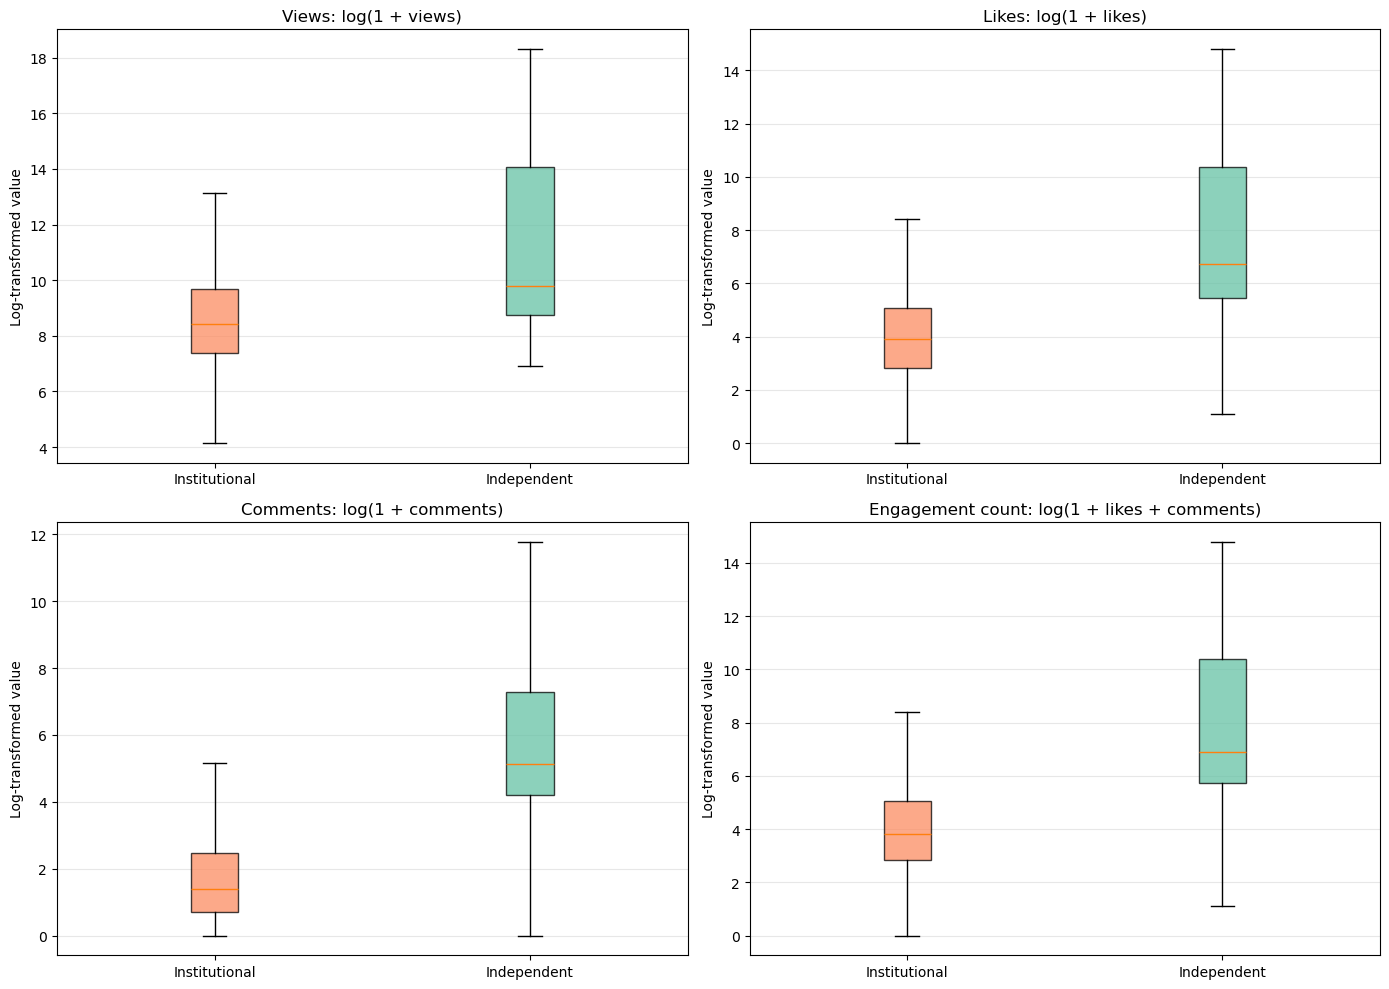

In [6]:
raw_metrics = [
    ("log_view_count", "Views: log(1 + views)"),
    ("log_like_count", "Likes: log(1 + likes)"),
    ("log_comment_count", "Comments: log(1 + comments)"),
    ("log_engagement_count", "Engagement count: log(1 + likes + comments)")
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (metric, title) in zip(axes, raw_metrics):
    box_data = [
        data.loc[data["Group"] == group, metric].dropna()
        for group in GROUP_ORDER
    ]
    bp = ax.boxplot(
        box_data,
        labels=GROUP_ORDER,
        patch_artist=True,
        showfliers=False
    )
    for patch, group in zip(bp["boxes"], GROUP_ORDER):
        patch.set_facecolor(COLOR_MAP[group])
        patch.set_alpha(0.75)

    ax.set_title(title)
    ax.set_ylabel("Log-transformed value")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## D. BOXPLOTS: ENGAGEMENT RATES

These boxplots compare engagement rates:
- Like rate = likes / views
- Comment rate = comments / views
- Engagement rate = (likes + comments) / views

For visual clarity, the y-axis is limited to the 99th percentile of each metric.  
The statistical tests below use the full data, not the clipped plot range.


/var/folders/kt/b3w2lybn0gvf5mhmrld2m4ph0000gn/T/ipykernel_1893/235530289.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/kt/b3w2lybn0gvf5mhmrld2m4ph0000gn/T/ipykernel_1893/235530289.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/kt/b3w2lybn0gvf5mhmrld2m4ph0000gn/T/ipykernel_1893/235530289.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


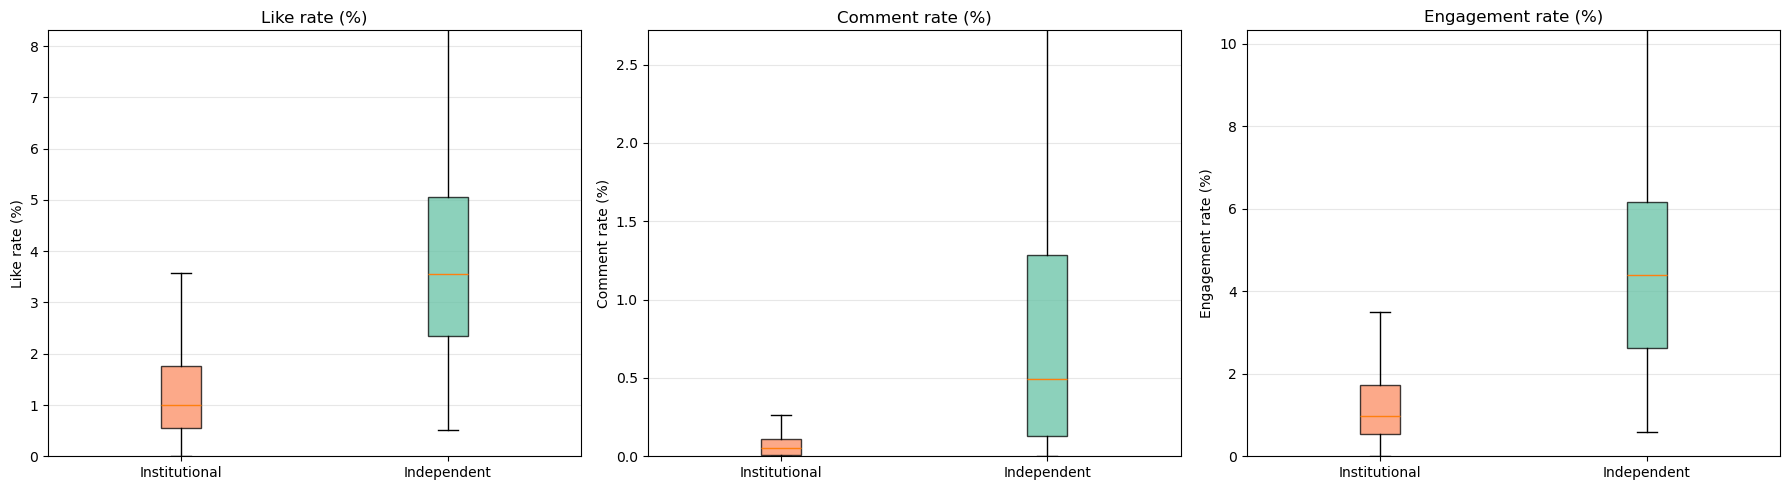

In [7]:
rate_metrics = [
    ("like_rate_pct", "Like rate (%)"),
    ("comment_rate_pct", "Comment rate (%)"),
    ("engagement_rate_pct", "Engagement rate (%)")
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (metric, title) in zip(axes, rate_metrics):
    plot_values = data[metric].replace([np.inf, -np.inf], np.nan).dropna()
    upper = plot_values.quantile(0.99)

    box_data = [
        data.loc[data["Group"] == group, metric].replace([np.inf, -np.inf], np.nan).dropna()
        for group in GROUP_ORDER
    ]

    bp = ax.boxplot(
        box_data,
        labels=GROUP_ORDER,
        patch_artist=True,
        showfliers=False
    )
    for patch, group in zip(bp["boxes"], GROUP_ORDER):
        patch.set_facecolor(COLOR_MAP[group])
        patch.set_alpha(0.75)

    ax.set_title(title)
    ax.set_ylabel(title)
    ax.set_ylim(0, upper)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## E. MANN–WHITNEY U TESTS: VIDEO LEVEL

The Mann–Whitney U test is used because engagement variables are not normally distributed.

Interpretation:
- A small p-value suggests that the institutional and independent distributions differ.
- The rank-biserial correlation is an effect-size measure.
- Positive effect size means the independent group tends to have higher values.
- Negative effect size means the institutional group tends to have higher values.

Caution: this video-level test treats videos as independent observations, but videos are nested within channels. Use this together with the channel-level tests below.


In [8]:
def mann_whitney_table(df, metrics, group_col="Group", group_a="Independent", group_b="Institutional"):
    rows = []

    for metric in metrics:
        a = df.loc[df[group_col] == group_a, metric].replace([np.inf, -np.inf], np.nan).dropna()
        b = df.loc[df[group_col] == group_b, metric].replace([np.inf, -np.inf], np.nan).dropna()

        if len(a) == 0 or len(b) == 0:
            rows.append({
                "metric": metric,
                "n_independent": len(a),
                "n_institutional": len(b),
                "median_independent": np.nan,
                "median_institutional": np.nan,
                "U": np.nan,
                "p_value": np.nan,
                "rank_biserial_effect_size": np.nan
            })
            continue

        u, p = mannwhitneyu(a, b, alternative="two-sided")

        # Rank-biserial correlation: positive means group_a tends to be higher than group_b
        rbc = (2 * u) / (len(a) * len(b)) - 1

        rows.append({
            "metric": metric,
            "n_independent": len(a),
            "n_institutional": len(b),
            "median_independent": a.median(),
            "median_institutional": b.median(),
            "U": u,
            "p_value": p,
            "rank_biserial_effect_size": rbc
        })

    return pd.DataFrame(rows)

video_level_metrics = [
    "view_count",
    "like_count",
    "comment_count",
    "engagement_count",
    "like_rate_pct",
    "comment_rate_pct",
    "engagement_rate_pct"
]

video_level_tests = mann_whitney_table(data, video_level_metrics)
display(video_level_tests.round(6))

,metric,n_independent,n_institutional,median_independent,median_institutional,U,p_value,rank_biserial_effect_size
0,view_count,2547,7021,18024.000000,4502.000000,13566546.5,0.0,0.517300
1,like_count,2548,6989,845.500000,48.000000,15666891.0,0.0,0.759537
2,comment_count,2544,6045,167.000000,3.000000,14448177.0,0.0,0.879012
3,engagement_count,2544,6023,1005.500000,45.000000,13734100.0,0.0,0.792670
4,like_rate_pct,2546,6983,3.551059,1.005587,15937139.0,0.0,0.792833
5,comment_rate_pct,2542,6041,0.491249,0.050692,13471678.0,0.0,0.754556
6,engagement_rate_pct,2542,6019,4.387804,0.968736,14009177.5,0.0,0.831229


## F. MANN–WHITNEY U TESTS: CHANNEL LEVEL

This is the more conservative comparison.  
First, each channel is reduced to its median value. Then the institutional and independent channel distributions are compared.

Because there are only 4 channels per group, p-values should be interpreted cautiously.


In [9]:
channel_medians_for_tests = (
    data.groupby(["Group", "channel_title"])[video_level_metrics]
    .median()
    .reset_index()
)

channel_level_tests = mann_whitney_table(channel_medians_for_tests, video_level_metrics)
display(channel_medians_for_tests.round(6))
display(channel_level_tests.round(6))

,Group,channel_title,view_count,like_count,comment_count,engagement_count,like_rate_pct,comment_rate_pct,engagement_rate_pct
0,Independent,3Blue1Brown,1762310.0,57154.0,1530.0,58240.0,3.056585,0.080224,3.173659
1,Independent,Kurzgesagt – In a Nutshell,8856190.5,305356.0,12099.5,323647.0,3.670653,0.125202,3.836465
2,Independent,Lectures by Walter Lewin. They will make you ♥...,8139.0,318.0,89.0,413.5,3.798758,1.048266,5.090979
3,Independent,minutephysics,1296104.0,25672.0,1675.0,27151.0,2.301251,0.137408,2.504623
4,Institutional,EPFL,2993.0,35.0,1.0,37.0,1.013241,0.032041,1.082335
5,Institutional,ETH Zürich,1633.5,27.0,1.0,28.0,1.626016,0.030253,1.708075
6,Institutional,Massachusetts Institute of Technology (MIT),11898.0,177.0,10.0,191.0,1.657279,0.085115,1.777390
7,Institutional,Stanford,5478.0,51.0,4.0,45.0,0.783875,0.050645,0.719209


,metric,n_independent,n_institutional,median_independent,median_institutional,U,p_value,rank_biserial_effect_size
0,view_count,4,4,1.529207e+06,4235.500000,15.0,0.057143,0.875
1,like_count,4,4,4.141300e+04,43.000000,16.0,0.028571,1.000
2,comment_count,4,4,1.602500e+03,2.500000,16.0,0.029401,1.000
3,engagement_count,4,4,4.269550e+04,41.000000,16.0,0.028571,1.000
4,like_rate_pct,4,4,3.363619e+00,1.319629,16.0,0.028571,1.000
5,comment_rate_pct,4,4,1.313050e-01,0.041343,15.0,0.057143,0.875
6,engagement_rate_pct,4,4,3.505062e+00,1.395205,16.0,0.028571,1.000


## G. ENGAGEMENT RATE THROUGHOUT THE EXISTENCE OF THE CHANNELS

This section tracks the median engagement rate over time.

Two time perspectives are used:
1. **Calendar year**: compares engagement by publication year.
2. **Years since the channel's first video in the dataset**: compares engagement over the internal lifespan of each channel.


,published_year,Group,videos,median_views,median_likes,median_comments,median_engagement_rate_pct
15,2017,Independent,190,20489.0,632.5,211.5,3.484
16,2017,Institutional,299,4049.0,46.0,3.0,1.151
17,2018,Independent,253,7096.0,316.0,112.0,5.379
18,2018,Institutional,423,3954.0,52.0,3.0,1.311
19,2019,Independent,207,6562.0,328.0,89.0,5.125
20,2019,Institutional,457,2628.0,39.0,2.0,1.550
21,2020,Independent,280,10690.5,590.5,154.5,6.371
22,2020,Institutional,384,3686.0,69.5,2.0,1.976
23,2021,Independent,246,18363.0,1078.0,217.5,6.993
24,2021,Institutional,314,4360.0,78.5,2.0,2.035


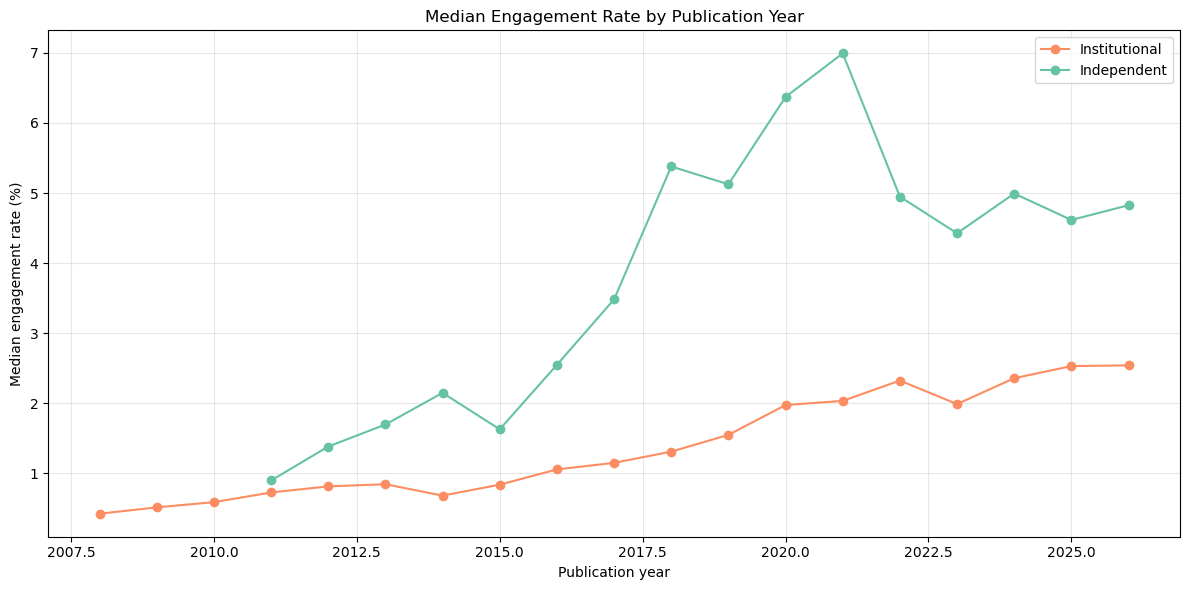

In [10]:
yearly_group_engagement = (
    data.groupby(["published_year", "Group"])
    .agg(
        videos=("video_id", "count"),
        median_views=("view_count", "median"),
        median_likes=("like_count", "median"),
        median_comments=("comment_count", "median"),
        median_engagement_rate_pct=("engagement_rate_pct", "median")
    )
    .reset_index()
    .sort_values(["published_year", "Group"])
)

display(yearly_group_engagement.tail(20).round(3))

plt.figure(figsize=(12, 6))

for group in GROUP_ORDER:
    subset = yearly_group_engagement[yearly_group_engagement["Group"] == group]
    plt.plot(
        subset["published_year"],
        subset["median_engagement_rate_pct"],
        marker="o",
        label=group,
        color=COLOR_MAP[group]
    )

plt.title("Median Engagement Rate by Publication Year")
plt.xlabel("Publication year")
plt.ylabel("Median engagement rate (%)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

,years_since_channel_first_video,Group,videos,median_engagement_rate_pct,median_views
0,0,Independent,341,1.547,85234.5
1,0,Institutional,631,0.429,23713.0
2,1,Independent,113,2.085,1670568.0
3,1,Institutional,377,0.535,7763.0
4,2,Independent,196,3.851,22578.5
5,2,Institutional,409,0.613,7568.0
6,3,Independent,252,5.380,6861.5
7,3,Institutional,393,0.729,6559.0
8,4,Independent,206,5.068,6902.0
9,4,Institutional,383,0.806,7517.0


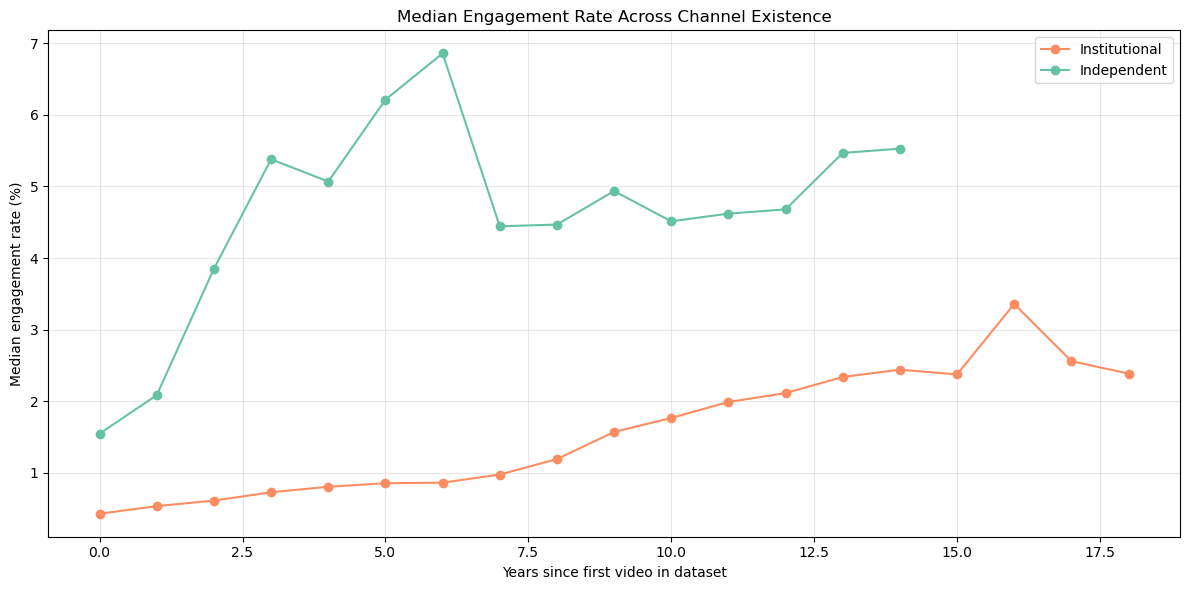

In [11]:
channel_age_engagement = (
    data.dropna(subset=["years_since_channel_first_video"])
    .groupby(["years_since_channel_first_video", "Group"])
    .agg(
        videos=("video_id", "count"),
        median_engagement_rate_pct=("engagement_rate_pct", "median"),
        median_views=("view_count", "median")
    )
    .reset_index()
    .sort_values(["years_since_channel_first_video", "Group"])
)

display(channel_age_engagement.head(20).round(3))

plt.figure(figsize=(12, 6))

for group in GROUP_ORDER:
    subset = channel_age_engagement[channel_age_engagement["Group"] == group]
    plt.plot(
        subset["years_since_channel_first_video"],
        subset["median_engagement_rate_pct"],
        marker="o",
        label=group,
        color=COLOR_MAP[group]
    )

plt.title("Median Engagement Rate Across Channel Existence")
plt.xlabel("Years since first video in dataset")
plt.ylabel("Median engagement rate (%)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## H. CHANNEL-SPECIFIC ENGAGEMENT TRAJECTORIES

This plot shows the yearly median engagement rate for each individual channel.  
It helps check whether the group pattern is driven by one channel or appears across multiple channels.


,published_year,Group_clean,channel_title,videos,median_engagement_rate_pct
99,2023,institutional,Stanford,42,3.500
107,2024,institutional,Stanford,70,NaN
115,2025,institutional,Stanford,73,2.564
123,2026,institutional,Stanford,10,2.449
6,2011,independent,minutephysics,28,0.900
11,2012,independent,minutephysics,54,1.384
17,2013,independent,minutephysics,38,1.722
23,2014,independent,minutephysics,25,2.174
31,2015,independent,minutephysics,17,2.396
39,2016,independent,minutephysics,24,3.083


['independent' 'institutional']


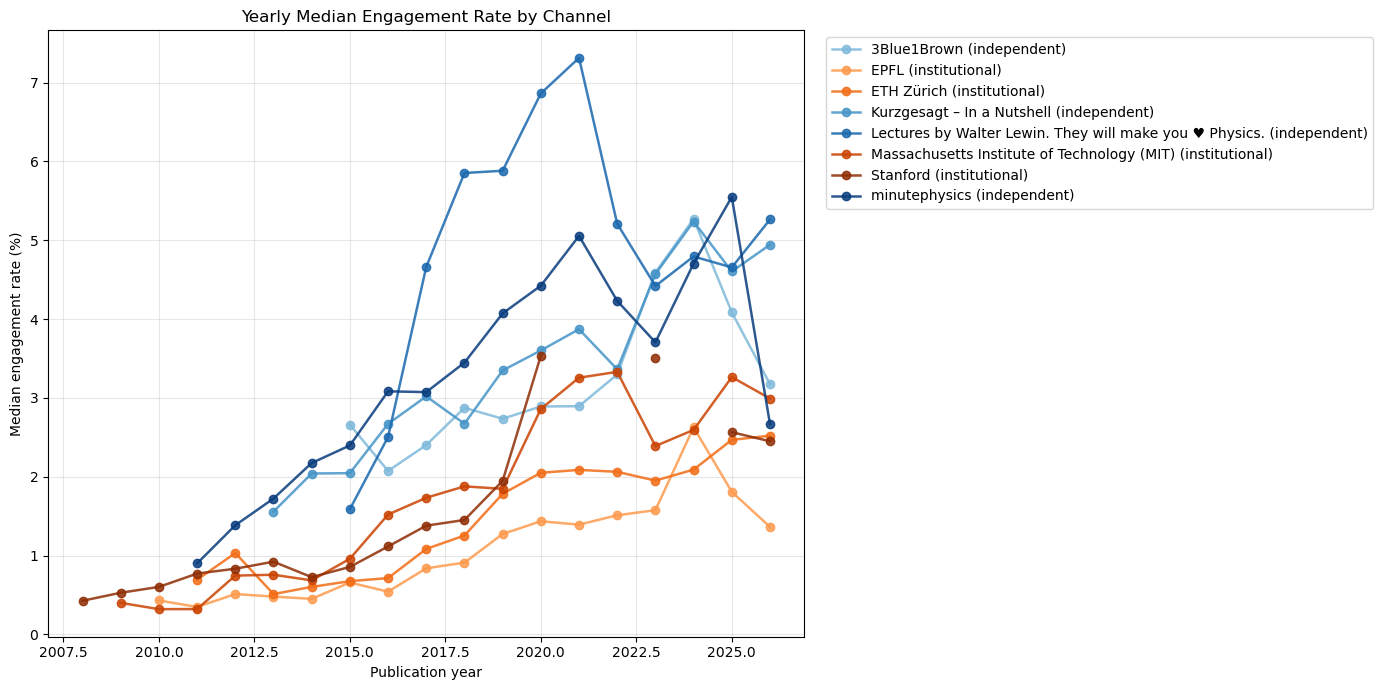

In [12]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Clean group labels
data["Group_clean"] = (
    data["Group"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Recreate yearly channel engagement table
yearly_channel_engagement = (
    data.groupby(["published_year", "Group_clean", "channel_title"])
    .agg(
        videos=("video_id", "count"),
        median_engagement_rate_pct=("engagement_rate_pct", "median")
    )
    .reset_index()
    .sort_values(["channel_title", "published_year"])
)

display(yearly_channel_engagement.tail(20).round(3))

# Check group labels
print(yearly_channel_engagement["Group_clean"].unique())

# Separate channels by group
independent_channels = sorted(
    yearly_channel_engagement.loc[
        yearly_channel_engagement["Group_clean"] == "independent",
        "channel_title"
    ].unique()
)

institutional_channels = sorted(
    yearly_channel_engagement.loc[
        yearly_channel_engagement["Group_clean"] == "institutional",
        "channel_title"
    ].unique()
)

# Create two gradients
independent_colors = cm.Blues(
    np.linspace(0.45, 0.95, len(independent_channels))
)

institutional_colors = cm.Oranges(
    np.linspace(0.45, 0.95, len(institutional_channels))
)

# Assign colors
channel_colors = {}

for channel, color in zip(independent_channels, independent_colors):
    channel_colors[channel] = color

for channel, color in zip(institutional_channels, institutional_colors):
    channel_colors[channel] = color

# Plot
plt.figure(figsize=(14, 7))

for channel, subset in yearly_channel_engagement.groupby("channel_title"):
    group = subset["Group_clean"].iloc[0]

    plt.plot(
        subset["published_year"],
        subset["median_engagement_rate_pct"],
        marker="o",
        linewidth=1.8,
        alpha=0.85,
        label=f"{channel} ({group})",
        color=channel_colors.get(channel, "gray")  # fallback avoids KeyError
    )

plt.title("Yearly Median Engagement Rate by Channel")
plt.xlabel("Publication year")
plt.ylabel("Median engagement rate (%)")
plt.grid(alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## I. EXPORT TABLES

This cell saves the main outputs as CSV files so they can be used in the written report.


In [13]:
output_dir = Path("outputs_part4_engagement")
output_dir.mkdir(exist_ok=True)

group_medians.to_csv(output_dir / "group_medians_engagement.csv")
channel_summary.to_csv(output_dir / "channel_summary_engagement.csv", index=False)
video_level_tests.to_csv(output_dir / "mann_whitney_video_level.csv", index=False)
channel_medians_for_tests.to_csv(output_dir / "channel_medians_for_tests.csv", index=False)
channel_level_tests.to_csv(output_dir / "mann_whitney_channel_level.csv", index=False)
yearly_group_engagement.to_csv(output_dir / "yearly_group_engagement.csv", index=False)
channel_age_engagement.to_csv(output_dir / "channel_age_engagement.csv", index=False)
yearly_channel_engagement.to_csv(output_dir / "yearly_channel_engagement.csv", index=False)

print("Saved outputs to:", output_dir.resolve())

Saved outputs to: /Users/oliviarobles/Downloads/CSM-projet/YouTubeCompare/analysis/person3_evolution/outputs_part4_engagement


## REPORT-READY SUMMARY TEMPLATE

Use the results above to complete this paragraph:

> Engagement was compared across institutional and independent channels using views, likes, comments, and normalized engagement rates. Because the distributions were highly skewed, medians were used as the main descriptive statistic, and Mann–Whitney U tests were used for group comparisons. At the video level, independent channels showed higher median engagement across [insert metrics]. Channel-level medians were also calculated to avoid over-weighting channels with many videos. The channel-level analysis [confirmed / partly confirmed / did not confirm] the video-level pattern. Engagement over time was assessed by publication year and by years since the first video in each channel, showing that [insert time-trend finding].
